In [22]:
import os
import re
import matplotlib.pyplot as plt
import json
import random
import sys
sys.path.append('../src') 

from collections import Counter
from langchain_text_splitters import RecursiveCharacterTextSplitter
from data_utils import create_documents_from_xml

In [23]:
root_dir = "documents/RU-DE/special language/press-sociopolitical/WHO/News WHO Europe"
root_dir = "documents"
raw_documents, files = create_documents_from_xml(root_dir)

file_to_save = "data/file_mapping_Splitters.json"
file_mapping_json = json.dumps(files, ensure_ascii=False)

with open(file_to_save, "w") as f:
    f.write(file_mapping_json)

print(f"Saved file mapping to {file_to_save}: {len(file_mapping_json):,} chars to {os.path.getsize(file_to_save):,} bytes.")
print(f"Total files parsed: {len(files):,}")
print(f"Total documents created: {len(raw_documents):,}")

Saved file mapping to data/file_mapping_Splitters.json: 43,921 chars to 52,361 bytes.
Total files parsed: 251
Total documents created: 231,377


In [24]:
raw_texts = [doc['text'] for doc in raw_documents]
print(f"Number of raw_texts: [{len(raw_texts):,} / {len(raw_documents):,}]")

Number of raw_texts: [231,377 / 231,377]


In [25]:
lower_texts = [text.lower() for text in raw_texts]
print(f"Number of lower_texts: [{len(lower_texts):,} / {len(raw_documents):,}]")

noise_pattern = r"[^\w .,:;!?]"
noise = set()

def clean_noise(text):
    matches = re.findall(noise_pattern, text)
    noise.update(matches)
    cleaned = re.sub(noise_pattern, '', text).strip()
    return cleaned

noiseless_texts = [clean_noise(text) for text in lower_texts]
print(f"Number of noiseless_texts: [{len(noiseless_texts):,} / {len(raw_documents):,}]")

print(f"\nCleaned noise:\n{noise}")  

Number of lower_texts: [231,377 / 231,377]
Number of noiseless_texts: [231,377 / 231,377]

Cleaned noise:
{'−', '-', '—', '€', '̈', '‘', '∙', '$', '\u200b', '▪', '×', '►', '{', '|', '·', '№', '\n', '◦', '`', '\t', '*', '»', '≥', '•', '\u200e', '=', '†', '(', '‒', '°', '‚', ')', "'", '̌', '&', '\xa0', '≤', '›', '<', '£', '\uf0a7', '~', '□', '%', '[', '^', '\u202f', '±', '„', '’', '‹', '…', '™', '\u2009', '́', '”', '/', '➜', '"', '¬', '●', '´', '“', '\xad', '>', '\\', '′', '\u2005', '©', '#', '§', ']', '@', '®', '→', '\u200a', '«', '–', '+'}


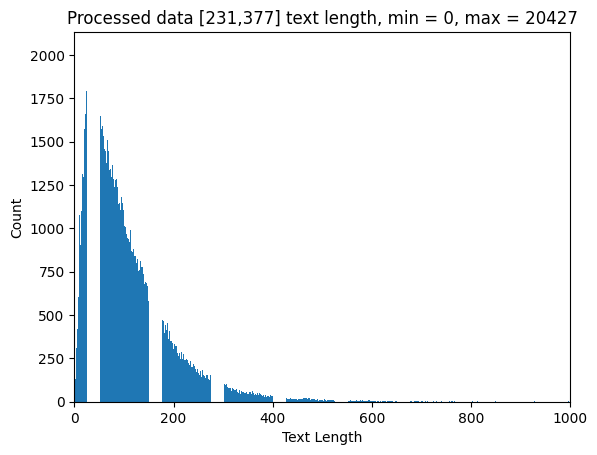

In [26]:
lengths = [len(text) for text in noiseless_texts]
counter = Counter(lengths)

plt.bar(counter.keys(), counter.values())
plt.xlim(0, 1000)
plt.xlabel("Text Length")
plt.ylabel("Count")
plt.title(f"Processed data [{len(lengths):,}] text length, min = {min(counter)}, max = {max(counter)}")
plt.show()

In [27]:
min_len = 50
max_len = 200

filtered_texts = [text for text in noiseless_texts if len(text) <= max_len]
print(f"Number of filtered_texts: [{len(filtered_texts):,} / {len(raw_documents):,}]")

Number of filtered_texts: [204,112 / 231,377]


In [28]:
def clean_text(text):
    cleaned = re.sub(r"[0-9.,:;!?]", "", text).strip()
    return cleaned
cleaned_filtered_texts = [clean_text(text) for text in filtered_texts]
print(f"Number of cleaned_filtered_texts: [{len(cleaned_filtered_texts):,} / {len(raw_documents):,}]")

Number of cleaned_filtered_texts: [204,112 / 231,377]


In [29]:
ready_texts = [text for text in cleaned_filtered_texts if len(text) >= min_len]
print(f"Number of ready_texts: [{len(ready_texts):,} / {len(raw_documents):,}]")

Number of ready_texts: [130,138 / 231,377]


In [30]:
sample = random.sample(ready_texts, min(len(ready_texts), 3))
for s in sample:
    print(f"- {s}")

- это официальный комментарий доступный в сети сейчас в качестве официального прессрелиза
- das sind die themen vertrag von aachen  weltwirtschaftsforum eröffnet  handballer im wmhalbfinale
- смене собственника имущества организации в отношении руководителя организации его заместителей и главного бухгалтера


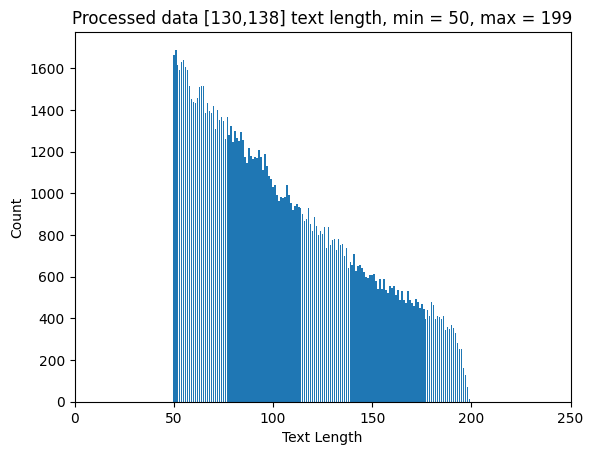

In [31]:
lengths = [len(text) for text in ready_texts]
counter = Counter(lengths)

plt.bar(counter.keys(), counter.values())
plt.xlim(0, 250)
plt.xlabel("Text Length")
plt.ylabel("Count")
plt.title(f"Processed data [{len(lengths):,}] text length, min = {min(counter)}, max = {max(counter)}")
plt.show()

In [32]:
big_texts = [text for text in noiseless_texts if len(text) > max_len]
small_texts = [text for text in noiseless_texts if len(text) < min_len]

print(f"{'Noiseless texts:':<20} {len(noiseless_texts):>10,}")
print(f"{'Ready texts:':<20} {len(ready_texts):>10,}  {min_len} <= len <= {max_len}")
print(f"{'Big texts:':<20} {len(big_texts):>10,}  len > {max_len}")
print(f"{'Small texts:':<20} {len(small_texts):>10,}  len < {min_len}")
print(f"\nFiltered [{len(filtered_texts):,}] + big [{len(big_texts):,}] + small [{len(small_texts):,}] = \
[{len(ready_texts) + len(big_texts) + len(small_texts):,} / {len(noiseless_texts):,}]")

print(f"Filtered + big: {len(filtered_texts) + len(big_texts):,}")
print(f"Filtered - ready: {len(filtered_texts) - len(ready_texts):,}")


Noiseless texts:        231,377
Ready texts:            130,138  50 <= len <= 200
Big texts:               27,265  len > 200
Small texts:             70,387  len < 50

Filtered [204,112] + big [27,265] + small [70,387] = [227,790 / 231,377]
Filtered + big: 231,377
Filtered - ready: 73,974


In [33]:
sample = random.sample(big_texts, min(len(big_texts), 3))
for s in sample:
    print(f"- {s}")

- эти совещания могли бы сосредоточивать свое внимание главным образом на проблемах сравнительных исследований и методики комплексного подхода к изучению социальных, социальноэкономических, экологических и культурных аспектов развития городов и изменения окружающей среды.
- 1. лица, обладающие полномочиями в отношении товаров, и их представители вправе совершать с товарами, находящимися на таможенном складе, обычные операции, необходимые для обеспечения сохранности товаров в неизменном состоянии, осматривать и измерять товары, перемещать их в пределах таможенного склада при условии, что эти операции не повлекут изменения состояния товаров, нарушения их упаковки и или изменения наложенных средств идентификации.
- термины cfr и cif в статьях а.8. сборника инкотермс 1990 обязывали продаца предоставлять копию чартерпартии во всех случаях, когда его транспортный документ обычно коносамент содержал ссылку на чартерпартию, например, посредством частного указания все прочие условия как для чар

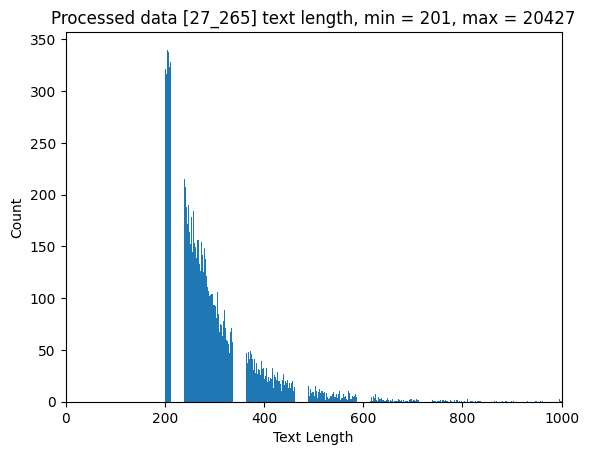

In [34]:
lengths = [len(text) for text in big_texts]
counter = Counter(lengths)

plt.bar(counter.keys(), counter.values())
plt.xlim(0, 1000)
plt.xlabel("Text Length")
plt.ylabel("Count")
plt.title(f"Processed data [{len(lengths):_}] text length, min = {min(counter)}, max = {max(counter)}")
plt.show()

In [35]:
splitter = RecursiveCharacterTextSplitter(
    chunk_size=200, 
    chunk_overlap=20,
    separators = [
        "\n\n",
        "\n",
        ". ",
        "... ",
        "! ",
        "? ",
        "; ",
        ": ",
        ", ",
        " ",
    ]
)
splitted_big_texts = []
for text in big_texts:
    splitted_big_texts += splitter.split_text(text)
    
print(f"From all {len(big_texts):,} big texts {len(splitted_big_texts):,} splitted_big_texts created.")

From all 27,265 big texts 67,155 splitted_big_texts created.


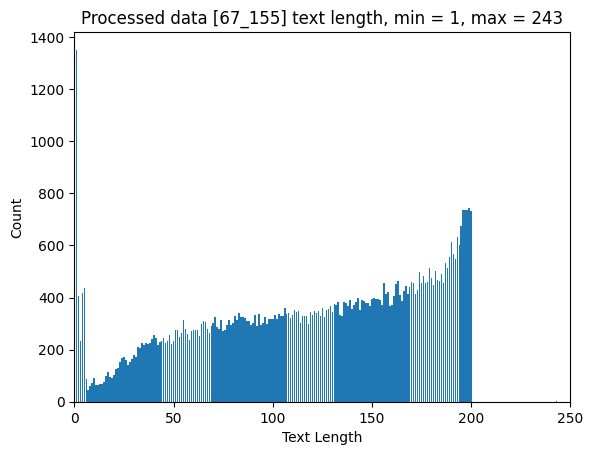

In [36]:
lengths = [len(text) for text in splitted_big_texts]
counter = Counter(lengths)

plt.bar(counter.keys(), counter.values())
plt.xlim(0, 250)
plt.xlabel("Text Length")
plt.ylabel("Count")
plt.title(f"Processed data [{len(lengths):_}] text length, min = {min(counter)}, max = {max(counter)}")
plt.show()

In [37]:
cleaned_splitted_big_texts = [clean_text(chunk) for chunk in splitted_big_texts]
ready_splitted_big_texts = [chunk for chunk in cleaned_splitted_big_texts if len(chunk) >= min_len]
print(f"Number of ready_splitted_big_texts [{len(ready_splitted_big_texts):,} / {len(cleaned_splitted_big_texts):,}]")

Number of ready_splitted_big_texts [56,531 / 67,155]


In [38]:
sample = random.sample(ready_splitted_big_texts, min(len(ready_splitted_big_texts), 1))
for s in sample:
    print(f"- {s}")

- wo kein eiserner vorhang den grenzüberschreitenden kontakt oder den warenverkehr behindert ist im bewusstsein vieler menschen selbstverständlich geworden


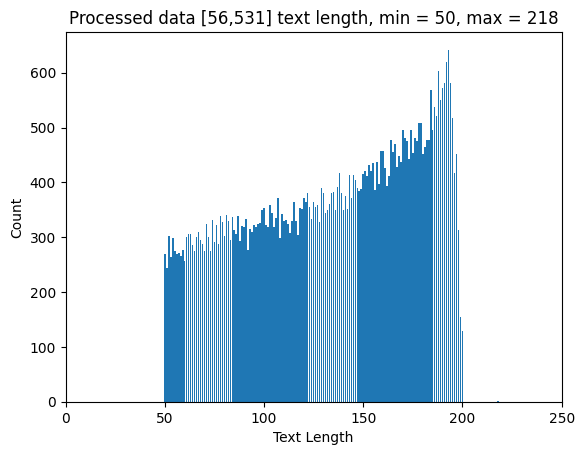

In [39]:
lengths = [len(text) for text in ready_splitted_big_texts]
counter = Counter(lengths)

plt.bar(counter.keys(), counter.values())
plt.xlim(0, 250)
plt.xlabel("Text Length")
plt.ylabel("Count")
plt.title(f"Processed data [{len(lengths):,}] text length, min = {min(counter)}, max = {max(counter)}")
plt.show()

In [40]:
print(f"Ready texts: {len(ready_texts):,}")
print(f"Ready splitted big texts: {len(ready_splitted_big_texts):,}")

Ready texts: 130,138
Ready splitted big texts: 56,531


In [41]:
db_texts = ready_texts + ready_splitted_big_texts
print(f"Number of db_texts: {len(db_texts):,} / {len(raw_texts):,}")

Number of db_texts: 186,669 / 231,377


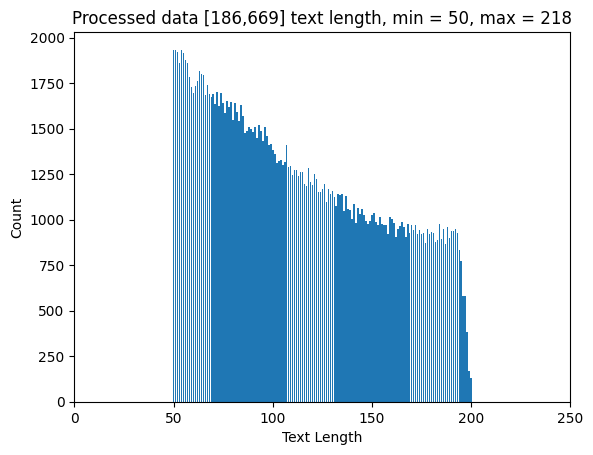

In [42]:
lengths = [len(text) for text in db_texts]
counter = Counter(lengths)

plt.bar(counter.keys(), counter.values())
plt.xlim(0, 250)
plt.xlabel("Text Length")
plt.ylabel("Count")
plt.title(f"Processed data [{len(lengths):,}] text length, min = {min(counter)}, max = {max(counter)}")
plt.show()